In [2]:
#vgsales.csvを使ってJPエリアで既に販売されているゲームで2026年の売り上げtop 10を予測する。
# ライブラリインポート

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
# データ読み込み
df = pd.read_csv("sample_data/vgsales.csv")

In [6]:
## 前処理
# 欠損確認
print(df.isnull().sum())

# 欠損処理
df = df.dropna(subset=["Year"])
df["Publisher"] = df["Publisher"].fillna("Unknown")

# 型変換
df["Year"] = df["Year"].astype(int)

# 不要列削除
df = df.drop(columns=["Rank"])

# 重複削除
df = df.drop_duplicates()

Rank              0
Name              0
Platform          0
Year            271
Genre             0
Publisher        58
NA_Sales          0
EU_Sales          0
JP_Sales          0
Other_Sales       0
Global_Sales      0
dtype: int64


In [7]:
#処理後の確認
print(df.isnull().sum())

Name            0
Platform        0
Year            0
Genre           0
Publisher       0
NA_Sales        0
EU_Sales        0
JP_Sales        0
Other_Sales     0
Global_Sales    0
dtype: int64


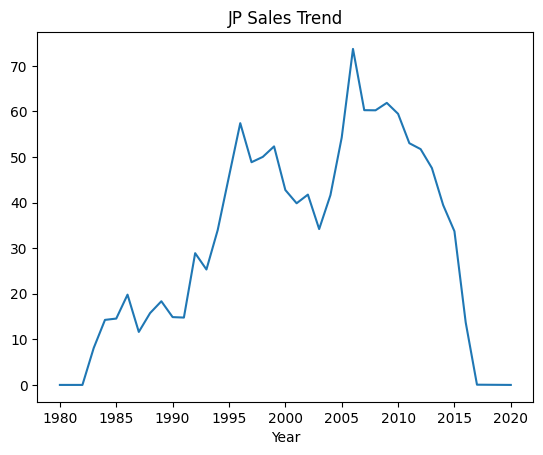

In [8]:
#可視化
year_sales = df.groupby("Year")["JP_Sales"].sum()

plt.figure()
year_sales.plot()
plt.title("JP Sales Trend")
plt.show()

In [ ]:
"""
販売トレンドの可視化の結果から2006年頃をピークに販売数は下降傾向である
"""

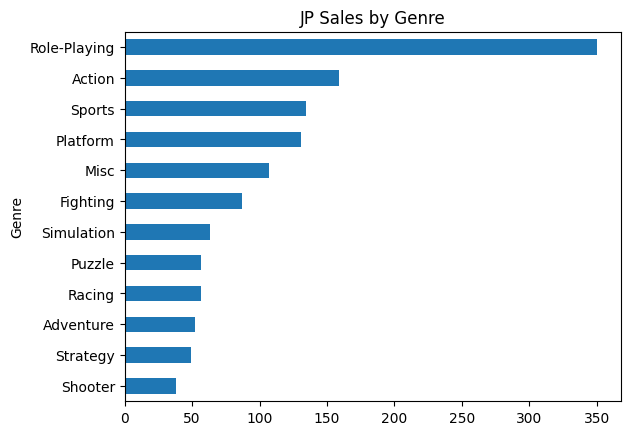

In [9]:
#ジャンルごとのJP売り上げ
genre_sales = df.groupby("Genre")["JP_Sales"].sum().sort_values()

plt.figure()
genre_sales.plot(kind="barh")
plt.title("JP Sales by Genre")
plt.show()

In [ ]:
"""
ジャンル毎の可視化結果からJPではRole-playingのジャンルが最も人気がある
"""

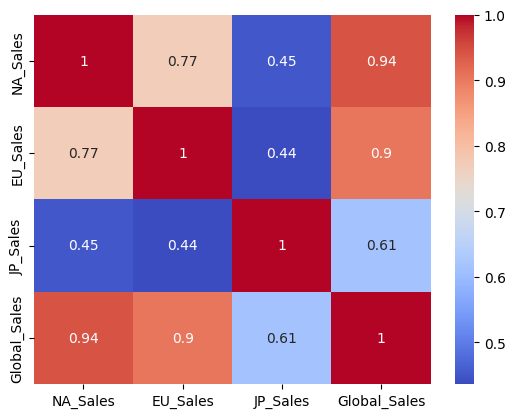

In [10]:
#他エリアとJPエリアの相関関係
corr = df[["NA_Sales","EU_Sales","JP_Sales","Global_Sales"]].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

In [ ]:
"""
JP salesとGlobal salesがNA, EUと比べて相関関係が高いと思われる。

In [12]:
#前処理・特徴量
df = df.dropna()

# 年を整数に
df["Year"] = df["Year"].astype(int)

In [13]:
#カテゴリ変数を変換
from sklearn.preprocessing import LabelEncoder

le_genre = LabelEncoder()
le_platform = LabelEncoder()
le_publisher = LabelEncoder()

df["Genre"] = le_genre.fit_transform(df["Genre"])
df["Platform"] = le_platform.fit_transform(df["Platform"])
df["Publisher"] = le_publisher.fit_transform(df["Publisher"])

In [14]:
#モデル作成（回帰）
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

X = df[["Year","Genre","Platform","Publisher","NA_Sales","EU_Sales"]]
y = df["JP_Sales"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = RandomForestRegressor(n_estimators=100)
model.fit(X_train, y_train)

RandomForestRegressor()

In [15]:
#2026年データ作成
future = df.copy()

future["Year"] = 2026

# NA / EU は過去平均で埋める（簡易）
future["NA_Sales"] = df["NA_Sales"].mean()
future["EU_Sales"] = df["EU_Sales"].mean()

In [16]:
#予測
future["Predicted_JP_Sales"] = model.predict(
    future[["Year","Genre","Platform","Publisher","NA_Sales","EU_Sales"]]
)

In [18]:
#Top 10を出す
top10 = future.sort_values("Predicted_JP_Sales", ascending=False).head(10)

#Genre, Platfor, Publisherは分析時に値に置き換えているので元の名称に戻す
top10["Genre"] = le_genre.inverse_transform(top10["Genre"])
top10["Platform"] = le_platform.inverse_transform(top10["Platform"])
top10["Publisher"] = le_publisher.inverse_transform(top10["Publisher"])

print(top10[["Name","Platform","Genre","Predicted_JP_Sales"]])

                                                    Name Platform      Genre  \
10653           Marvel vs. Capcom: Clash of Super Heroes       DC   Fighting   
9672         Capcom vs. SNK 2: Millionaire Fighting 2001       DC   Fighting   
13242          Capcom vs. SNK: Millennium Fight 2000 Pro       DC   Fighting   
1650                 Super Street Fighter IV: 3D Edition      3DS   Fighting   
15863                                  Gaist Crusher God      3DS     Action   
4020                   Resident Evil: The Mercenaries 3D      3DS     Action   
7782   Great Phoenix Wright: Ace Attorney - Naruhodou...      3DS     Action   
9184    Monster Hunter Diary: Poka Poka Airou Village DX      3DS     Action   
6390                                      Ace Attorney 6      3DS  Adventure   
15829               Phoenix Wright: Ace Attorney Trilogy      3DS  Adventure   

       Predicted_JP_Sales  
10653              0.8194  
9672               0.8194  
13242              0.8194  
1650   